<a href="https://colab.research.google.com/github/songwonni040122-ops/2026.08.Garbage-classification-model/blob/main/2026_08_trash_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.데이터 불러오기
=

In [ ]:
import os
from google.colab import userdata

# 금고에서 토큰 받아오기
token = userdata.get('KAGGLE_KEY')

# 환경 변수에 토큰 등록
os.environ['KAGGLE_API_TOKEN'] = token

In [ ]:
import kagglehub

# garbage-classification 데이터셋 내려받기
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("데이터 저장 경로:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
데이터 저장 경로: /kaggle/input/garbage-classification


In [ ]:
# 데이터셋 폴더 구조확인
for root, dirs, files in os.walk(path):
    print(root, "| 폴더:", len(dirs), "| 파일:", len(files))

/kaggle/input/garbage-classification | 폴더: 2 | 파일: 5
/kaggle/input/garbage-classification/Garbage classification | 폴더: 1 | 파일: 0
/kaggle/input/garbage-classification/Garbage classification/Garbage classification | 폴더: 6 | 파일: 0
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/metal | 폴더: 0 | 파일: 410
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/glass | 폴더: 0 | 파일: 501
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/paper | 폴더: 0 | 파일: 594
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/trash | 폴더: 0 | 파일: 137
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/cardboard | 폴더: 0 | 파일: 403
/kaggle/input/garbage-classification/Garbage classification/Garbage classification/plastic | 폴더: 0 | 파일: 482
/kaggle/input/garbage-classification/garbage classification | 폴더: 1 | 파일: 0
/kaggle/input/garbage-classification/garbage cla

In [ ]:
# 사용할 클래스 폴더 경로
data_dir = "/kaggle/input/garbage-classification/Garbage classification/Garbage classification"

# 클래스 6종 확인, 점검완료
print(os.listdir(data_dir))

['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [ ]:
import shutil
import os

# 원본 데이터 복사
src = data_dir

# Google Drive 내 저장할 경로 지정
dst = "/content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/Garbage-data"

# 폴더가 없을 시 새로 만들기 (환경이 바뀌면 동작하지 않을 경우를 대비)
os.makedirs(dst, exist_ok=True)

# 폴더 복사 (이미 있으면 덮어씀)
shutil.copytree(src, dst, dirs_exist_ok=True)

print("복사 완료")
print("드라이브에 저장된 클래스:", os.listdir(dst))

복사 완료
드라이브에 저장된 클래스: ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [21]:
# Google Drive 폴더로 데이터 경로 설정
data_dir = "/content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/Garbage-data"

# 확인
print(os.listdir(data_dir))

['trash', 'cardboard', 'plastic', 'metal', 'glass', 'paper']


In [29]:
# ===== 기본환경 세팅 (데이터 가져오기/기본 도구 불러오기) =====

# 1. 기본 도구 불러오기
import os
import shutil

# 2. Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

# 3. 데이터 경로 지정
data_dir = "/content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/Garbage-data"

# 4. 세팅 확인
print("세팅 완료")
print("클래스:", os.listdir(data_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
세팅 완료
클래스: ['trash', 'cardboard', 'plastic', 'metal', 'glass', 'paper']


2.데이터 전처리
=

In [2]:
from torchvision import datasets

# data_dir 폴더를 읽어서 데이터 묶음으로 만듦
# 하위 폴더(cardboard, glass 등) 이름을 클래스로 자동 인식
dataset = datasets.ImageFolder(data_dir)

# 인식된 클래스 이름 목록 출력
print("클래스:", dataset.classes)

# 데이터 묶음 내 이미지 개수 출력
print("이미지 총 개수:", len(dataset))

클래스: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
이미지 총 개수: 2527


In [3]:
# 데이터 묶음에서 첫 번째(0번) 항목을 꺼냄
# 사진 한 장과 그 정답 번호가 같이 나옴 -> 각각 image, label에 담음
image, label = dataset[0]

# 꺼낸 정답 번호가 몇 번인지 출력
print("정답 번호:", label)

# 그 번호가 어떤 클래스 이름인지 출력 (번호를 이름으로 바꿔봄)
print("정답 이름:", dataset.classes[label])

정답 번호: 0
정답 이름: cardboard


In [4]:
from collections import Counter

# Counter로 각 번호(class 번호)가 몇 번씩 나오는지 셈
counts = Counter(dataset.targets)

# 번호 순서대로(0~5) 클래스 이름과 개수를 같이 출력
for label_num in range(len(dataset.classes)):
    class_name = dataset.classes[label_num]   # 번호 -> 이름
    count = counts[label_num]                 # 그 번호가 몇 장인지
    print(class_name, ":", count, "장")

cardboard : 403 장
glass : 501 장
metal : 410 장
paper : 594 장
plastic : 482 장
trash : 137 장


In [5]:
from torchvision import transforms

# 전처리 규칙 정의
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 모든 사진을 가로 224, 세로 224로 크기 통일
    transforms.ToTensor(),  # 사진을 숫자 덩어리로 변환 (값 범위 0~1)
    transforms.Normalize(           # 값을 ResNet 기준에 맞게 재조정
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 위 규칙을 적용해서 dataset을 새 버전으로 덮어씀
dataset = datasets.ImageFolder(data_dir, transform=transform)

# 확인
image, label = dataset[0]
print("모양(shape):", image.shape)
print("값 최소:", image.min().item(), "/ 값 최대:", image.max().item())

모양(shape): torch.Size([3, 224, 224])
값 최소: -1.9466564655303955 / 값 최대: 2.129034996032715


In [6]:
from sklearn.model_selection import train_test_split

# 나눌 대상은 "사진 번호" 0부터 2526까지 (전체 인덱스)
indices = range(len(dataset))

# 각 사진의 정답 번호 목록 (층화 분할 기준)
labels = dataset.targets

# 1차 분할: 전체를 train(70%) 과 나머지(30%)로 나눔
# stratify=labels -> 클래스 비율을 유지하며 나누라는 뜻
# random_state=42 -> 나누는 방식 고정
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=labels,
    random_state=42,
)

# 2차 분할: 위에서 남긴 30%를 val 과 test로 절반씩 나눔 (각 15%)
# temp_idx에 해당하는 정답들만 골라 다시 층화 기준으로 사용
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42,
)

# 각 묶음에 사진이 몇 장씩 들어갔는지 확인
print("학습용:", len(train_idx), "장")
print("검증용:", len(val_idx), "장")
print("테스트용:", len(test_idx), "장")

학습용: 1768 장
검증용: 379 장
테스트용: 380 장


In [7]:
from collections import Counter

# 각 묶음의 정답 번호만 골라냄
train_labels = [labels[i] for i in train_idx]
val_labels   = [labels[i] for i in val_idx]
test_labels  = [labels[i] for i in test_idx]

# 클래스별로 몇 장씩 들어갔는지 출력
print("클래스별 (학습 / 검증 / 테스트)")
for num in range(len(dataset.classes)):
    name = dataset.classes[num]
    tr = Counter(train_labels)[num]   # 학습용
    va = Counter(val_labels)[num]     # 검증용
    te = Counter(test_labels)[num]    # 테스트용
    print(f"{name:10s}: {tr:4d} / {va:3d} / {te:3d}")

클래스별 (학습 / 검증 / 테스트)
cardboard :  282 /  61 /  60
glass     :  350 /  75 /  76
metal     :  287 /  61 /  62
paper     :  416 /  89 /  89
plastic   :  337 /  72 /  73
trash     :   96 /  21 /  20


In [8]:
from torch.utils.data import Subset

#  두가지로 나누어 전처리 ---------------------------------------------

# 학습용 전처리 (나중에 필요시 데이터 증강 예정)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),          # 숫자로 변환
    transforms.Normalize(           # 정규화
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 평가용 전처리 (검증·테스트용. 증강 x)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 같은 폴더를 전처리만 다르게 두 번 Read -----------------------------

# 학습용 전처리가 붙은 전체 묶음
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

# 평가용 전처리가 붙은 전체 묶음
eval_base  = datasets.ImageFolder(data_dir, transform=eval_transform)


# 번호표로 세 묶음 갈라내기 ------------------------------------------

# 학습용: 학습용 전처리 묶음에서 train 번호만 뽑음
train_dataset = Subset(train_base, train_idx)

# 검증용: 평가용 전처리 묶음에서 val 번호만 뽑음
val_dataset   = Subset(eval_base, val_idx)

# 테스트용: 평가용 전처리 묶음에서 test 번호만 뽑음
test_dataset  = Subset(eval_base, test_idx)

In [9]:
# 확인
print("학습용:", len(train_dataset), "장")
print("검증용:", len(val_dataset), "장")
print("테스트용:", len(test_dataset), "장")
print("클래스별 (학습 / 검증 / 테스트)")
for num in range(len(train_base.classes)):
    name = train_base.classes[num]
    tr = Counter(train_labels)[num]
    va = Counter(val_labels)[num]
    te = Counter(test_labels)[num]
    print(f"{name:10s}: {tr:4d} / {va:3d} / {te:3d}")

학습용: 1768 장
검증용: 379 장
테스트용: 380 장
클래스별 (학습 / 검증 / 테스트)
cardboard :  282 /  61 /  60
glass     :  350 /  75 /  76
metal     :  287 /  61 /  62
paper     :  416 /  89 /  89
plastic   :  337 /  72 /  73
trash     :   96 /  21 /  20


In [10]:
from torch.utils.data import DataLoader

# 배치 크기: 한 번에 32장씩 묶어서 처리 (하이퍼파라미터, 일단 무난한 값으로 시작)
batch_size = 32

# 학습용 로더: 학습 때는 순서를 섞음 (shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 검증용 로더: 성적 측정용이라 섞을 필요 없음 (shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 테스트용 로더: 마찬가지로 안 섞음
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 확인: 배치가 몇 개씩 나오는지, 배치 하나의 모양은 어떤지
print("학습용 배치 개수:", len(train_loader))
print("검증용 배치 개수:", len(val_loader))
print("테스트용 배치 개수:", len(test_loader))

# 학습용 로더에서 배치 하나만 꺼내서 모양 확인
images, labels_batch = next(iter(train_loader))
print("배치 이미지 모양:", images.shape)
print("배치 정답 모양:", labels_batch.shape)

학습용 배치 개수: 56
검증용 배치 개수: 12
테스트용 배치 개수: 12
배치 이미지 모양: torch.Size([32, 3, 224, 224])
배치 정답 모양: torch.Size([32])


### 3. 모델학습

In [11]:
import torch
from torchvision import models
from torchvision.models import ResNet18_Weights

# ResNet18 불러오기 (구조 + 사전학습된 가중치 함께)
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# 마지막 출력층(fc) 구조 확인
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Linear(in_features=512, out_features=1000, bias=True)


In [12]:
import torch.nn as nn

# 1. 앞 덩어리 전체를 얼리기 (학습 중 가중치 고정)
for param in model.parameters():
    param.requires_grad = False

# 2. fc층을 6개짜리 새 선형층으로 교체
num_classes = 6
model.fc = nn.Linear(in_features=512, out_features=num_classes)

# 3. 확인
print(model.fc)

Linear(in_features=512, out_features=6, bias=True)


In [13]:
# 1. 사용 가능한 장치 결정 (GPU 있으면 GPU, 없으면 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

# 2. 모델을 그 장치로 이동
model = model.to(device)

사용 장치: cuda


In [14]:
import torch.optim as optim

# 1. 손실 함수
criterion = nn.CrossEntropyLoss()

# 2. 최적화 방법: Adam으로 조정, 학습률 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
import shutil, os

# 원본: 드라이브 (영구 보관)
drive_data = "/content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/Garbage-data"

# 복사본: Colab 내부 저장소
local_data = "/content/Garbage-data"

# 이미 복사돼 있으면 건너뛰고, 없으면 복사
if not os.path.exists(local_data):
    shutil.copytree(drive_data, local_data)
    print("내부 저장소로 복사 완료")
else:
    print("이미 복사돼 있음")

# 앞으로 학습은 이 경로 사용
data_dir = local_data
print("현재 data_dir:", data_dir)
print("클래스:", os.listdir(data_dir))

내부 저장소로 복사 완료
현재 data_dir: /content/Garbage-data
클래스: ['plastic', 'cardboard', 'paper', 'metal', 'trash', 'glass']


In [16]:
from torchvision import datasets
from torch.utils.data import Subset, DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

num_epochs = 10

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/10 | 학습 손실: 1.3339 | 검증 손실: 0.9948 | 검증 정확도: 65.96%
에폭 2/10 | 학습 손실: 0.8608 | 검증 손실: 0.8015 | 검증 정확도: 70.45%
에폭 3/10 | 학습 손실: 0.7218 | 검증 손실: 0.7551 | 검증 정확도: 73.61%
에폭 4/10 | 학습 손실: 0.6154 | 검증 손실: 0.6711 | 검증 정확도: 75.73%
에폭 5/10 | 학습 손실: 0.5781 | 검증 손실: 0.6377 | 검증 정확도: 76.52%
에폭 6/10 | 학습 손실: 0.5442 | 검증 손실: 0.6426 | 검증 정확도: 76.52%
에폭 7/10 | 학습 손실: 0.5177 | 검증 손실: 0.6151 | 검증 정확도: 76.52%
에폭 8/10 | 학습 손실: 0.4738 | 검증 손실: 0.5976 | 검증 정확도: 76.78%
에폭 9/10 | 학습 손실: 0.4500 | 검증 손실: 0.5955 | 검증 정확도: 77.57%
에폭 10/10 | 학습 손실: 0.4463 | 검증 손실: 0.5817 | 검증 정확도: 79.16%


              precision    recall  f1-score   support

   cardboard       1.00      0.85      0.92        61
       glass       0.76      0.76      0.76        75
       metal       0.70      0.82      0.76        61
       paper       0.82      0.94      0.88        89
     plastic       0.72      0.67      0.69        72
       trash       0.75      0.43      0.55        21

    accuracy                           0.79       379
   macro avg       0.79      0.75      0.76       379
weighted avg       0.80      0.79      0.79       379



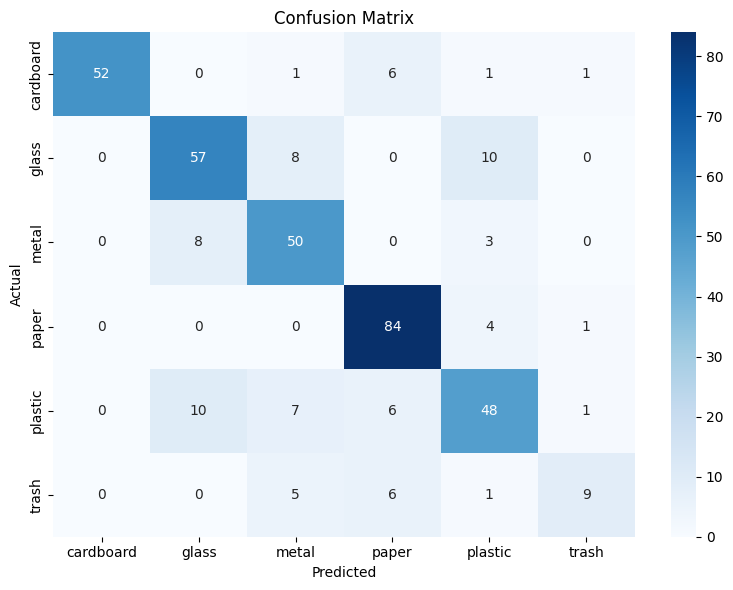

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt   # 그림 그리는 도구
import seaborn as sns             # 히트맵을 쉽게 그려주는 도구

# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

4.데이터 증강
=
- trash 를 정확히 판별하지 못하는 문제 발생
- 기존의 사진 데이터를 뒤집기, 회전, 색변형 등으로 증강 후 성능 비교

In [20]:
from torchvision import transforms

# 학습용 전처리 (증강 포함)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # 크기 통일
    transforms.RandomHorizontalFlip(p=0.5),  # 50% 확률로 좌우 뒤집기
    transforms.RandomRotation(degrees=15),   # -15~+15도 사이 무작위 회전
    transforms.ColorJitter(                  # 색 변형
        brightness=0.2,                      # 밝기 ±20% 변동
        contrast=0.2,                        # 대비 ±20% 변동
    ),
    transforms.ToTensor(),                   # 숫자 덩어리로 변환
    transforms.Normalize(                    # ImageNet 기준으로 값 재조정
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [21]:
# 현재 살아있는 관련 변수 이름 확인
for name in ["train_base", "eval_base", "train_idx", "val_idx", "test_idx",
             "train_dataset", "val_dataset", "test_dataset"]:
    print(name, "→", "있음" if name in dir() else "없음")

train_base → 있음
eval_base → 있음
train_idx → 있음
val_idx → 있음
test_idx → 있음
train_dataset → 있음
val_dataset → 있음
test_dataset → 있음


In [22]:
from torchvision import datasets
from torch.utils.data import Subset, DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

# ===== 1. train_base 다시 만들기 (새 증강 반영) =====
# eval_base는 증강과 무관하므로 그대로 두고, train_base만 새 transform으로 재생성
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

# ===== 2. Subset 다시 만들기 (기존 인덱스 그대로 사용) =====
# 인덱스(train_idx 등)는 데이터를 어떻게 나눴는지의 기록이라 그대로 재사용
train_dataset = Subset(train_base, train_idx)   # 학습용: 새 증강 적용됨
val_dataset   = Subset(eval_base, val_idx)      # 검증용: 증강 없음(그대로)
test_dataset  = Subset(eval_base, test_idx)     # 테스트용: 증강 없음(그대로)

# ===== 3. DataLoader 다시 만들기 =====
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ===== 4. 모델 처음 상태로 다시 준비 =====
# 사전학습 ResNet18을 새로 불러옴 (10에폭 학습된 기존 model을 덮어씀)
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# 앞 덩어리 전체 얼리기
for param in model.parameters():
    param.requires_grad = False

# fc층을 6개짜리로 교체 (이 층만 학습됨)
model.fc = nn.Linear(in_features=512, out_features=6)

# GPU로 이동
model = model.to(device)

# ===== 5. 손실 함수 · 최적화 방법 새로 만들기 =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("준비 완료 - 증강 반영된 데이터 + 초기화된 모델")

준비 완료 - 증강 반영된 데이터 + 초기화된 모델


In [24]:
num_epochs = 15  #방식 특성상 에폭수를 1.5배로 조정

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/15 | 학습 손실: 1.1419 | 검증 손실: 1.0151 | 검증 정확도: 62.53%
에폭 2/15 | 학습 손실: 0.8884 | 검증 손실: 0.9270 | 검증 정확도: 66.23%
에폭 3/15 | 학습 손실: 0.7785 | 검증 손실: 0.8755 | 검증 정확도: 65.17%
에폭 4/15 | 학습 손실: 0.7101 | 검증 손실: 0.7856 | 검증 정확도: 69.66%
에폭 5/15 | 학습 손실: 0.6563 | 검증 손실: 0.7533 | 검증 정확도: 71.77%
에폭 6/15 | 학습 손실: 0.6141 | 검증 손실: 0.7221 | 검증 정확도: 72.56%
에폭 7/15 | 학습 손실: 0.6004 | 검증 손실: 0.7451 | 검증 정확도: 72.30%
에폭 8/15 | 학습 손실: 0.5921 | 검증 손실: 0.7106 | 검증 정확도: 72.82%
에폭 9/15 | 학습 손실: 0.5558 | 검증 손실: 0.7665 | 검증 정확도: 71.24%
에폭 10/15 | 학습 손실: 0.5510 | 검증 손실: 0.7067 | 검증 정확도: 74.14%
에폭 11/15 | 학습 손실: 0.5327 | 검증 손실: 0.7558 | 검증 정확도: 72.03%
에폭 12/15 | 학습 손실: 0.5530 | 검증 손실: 0.7833 | 검증 정확도: 71.24%
에폭 13/15 | 학습 손실: 0.5049 | 검증 손실: 0.7025 | 검증 정확도: 75.20%
에폭 14/15 | 학습 손실: 0.5084 | 검증 손실: 0.6833 | 검증 정확도: 77.04%
에폭 15/15 | 학습 손실: 0.5020 | 검증 손실: 0.7573 | 검증 정확도: 73.35%


              precision    recall  f1-score   support

   cardboard       0.98      0.74      0.84        61
       glass       0.81      0.59      0.68        75
       metal       0.57      0.92      0.70        61
       paper       0.84      0.78      0.81        89
     plastic       0.65      0.75      0.70        72
       trash       0.67      0.48      0.56        21

    accuracy                           0.73       379
   macro avg       0.75      0.71      0.71       379
weighted avg       0.77      0.73      0.74       379



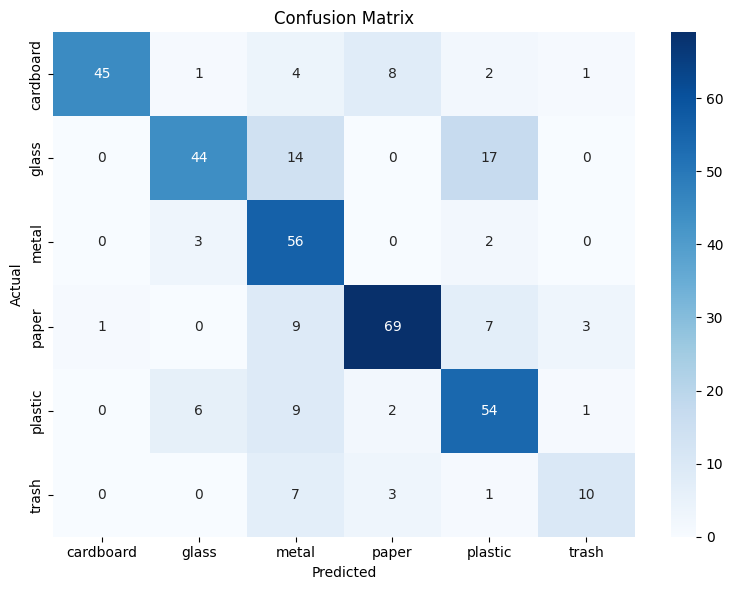

In [25]:
# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

5.손실가중치 수정
=
- 사진을 회전시키는 작업만으로는 모델의 성능을 올리기 부족. (trash 클래스의 재현율 증가폭은 미미, 다른 클래스의 성능저하)
- 자료 수가 적은 클래스는 손실가중치를 올리는 방식으로 새로운 학습 진행/비교

In [26]:
from torchvision import transforms, datasets, models
from torchvision.models import ResNet18_Weights
from torch.utils.data import Subset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
from collections import Counter

# ===== 1. train_transform을 증강 없는 버전으로 되돌리기 =====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# ===== 2. 데이터셋·로더 다시 만들기 (증강 빠진 상태 반영) =====
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(eval_base, val_idx)
test_dataset  = Subset(eval_base, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ===== 3. 클래스별 가중치 계산 (장수의 역수 기반) =====
# 학습셋의 실제 정답(label)만 모아서 클래스별 장수를 셈
train_labels = [train_base.targets[i] for i in train_idx]
counts = Counter(train_labels)              # {클래스번호: 장수}

num_classes = 6
# 클래스 번호 0~5 순서대로 장수를 나열
class_counts = torch.tensor(
    [counts[c] for c in range(num_classes)], dtype=torch.float
)

# 가중치 = 전체장수 / (클래스수 × 각클래스장수)  → 적을수록 큰 값
class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = class_weights.to(device)

print("클래스별 장수:", class_counts.tolist())
print("클래스별 가중치:", [round(w, 3) for w in class_weights.tolist()])

# ===== 4. 모델 초기화 =====
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(in_features=512, out_features=num_classes)
model = model.to(device)

# ===== 5. 손실 함수에 가중치 적용 + 옵티마이저 =====
criterion = nn.CrossEntropyLoss(weight=class_weights)   # 여기가 핵심
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("준비 완료 - 증강 없음 + 손실 가중치 적용 + 초기화된 모델")

클래스별 장수: [282.0, 350.0, 287.0, 416.0, 337.0, 96.0]
클래스별 가중치: [1.045, 0.842, 1.027, 0.708, 0.874, 3.069]
준비 완료 - 증강 없음 + 손실 가중치 적용 + 초기화된 모델


In [27]:
num_epochs = 10

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/10 | 학습 손실: 1.3743 | 검증 손실: 1.0592 | 검증 정확도: 60.16%
에폭 2/10 | 학습 손실: 0.9138 | 검증 손실: 0.8947 | 검증 정확도: 72.82%
에폭 3/10 | 학습 손실: 0.7529 | 검증 손실: 0.7876 | 검증 정확도: 72.82%
에폭 4/10 | 학습 손실: 0.6762 | 검증 손실: 0.7626 | 검증 정확도: 75.20%
에폭 5/10 | 학습 손실: 0.6197 | 검증 손실: 0.7364 | 검증 정확도: 74.93%
에폭 6/10 | 학습 손실: 0.5926 | 검증 손실: 0.6891 | 검증 정확도: 75.20%
에폭 7/10 | 학습 손실: 0.5246 | 검증 손실: 0.7140 | 검증 정확도: 77.04%
에폭 8/10 | 학습 손실: 0.4970 | 검증 손실: 0.6718 | 검증 정확도: 75.46%
에폭 9/10 | 학습 손실: 0.4898 | 검증 손실: 0.7079 | 검증 정확도: 77.84%
에폭 10/10 | 학습 손실: 0.4900 | 검증 손실: 0.6499 | 검증 정확도: 77.04%


              precision    recall  f1-score   support

   cardboard       0.95      0.87      0.91        61
       glass       0.79      0.71      0.75        75
       metal       0.71      0.74      0.73        61
       paper       0.89      0.82      0.85        89
     plastic       0.67      0.75      0.71        72
       trash       0.47      0.67      0.55        21

    accuracy                           0.77       379
   macro avg       0.75      0.76      0.75       379
weighted avg       0.79      0.77      0.78       379



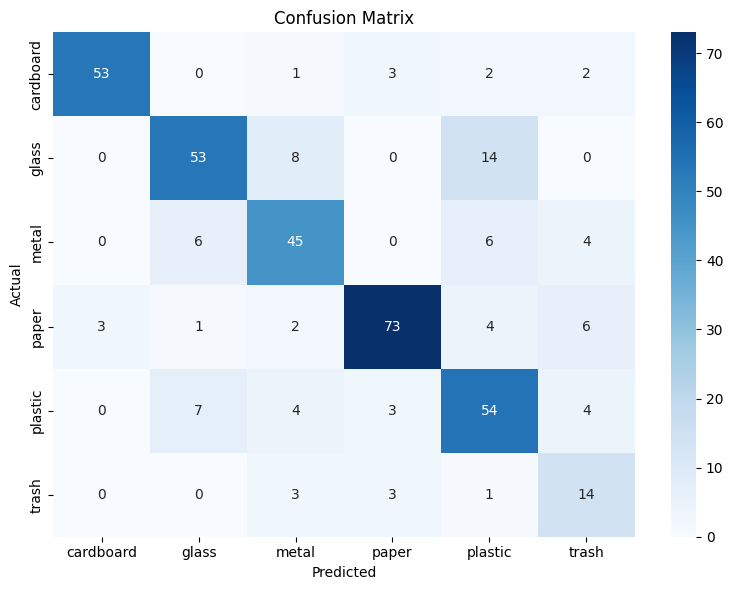

In [28]:
# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

In [37]:
# ===== 1. train_transform: 증강 없는 ver =====
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# ===== 2. 데이터셋·로더 다시 만들기 =====
# eval_base는 그대로 재사용, train_base만 새로 만듦
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(eval_base, val_idx)
test_dataset  = Subset(eval_base, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ===== 3. 클래스별 가중치 계산 (제곱근으로 강도 완화) =====
train_labels = [train_base.targets[i] for i in train_idx]
counts = Counter(train_labels)

num_classes = 6
class_counts = torch.tensor(
    [counts[c] for c in range(num_classes)], dtype=torch.float
)

# 기존 방식: 전체장수 / (클래스수 × 각클래스장수)
raw_weights = class_counts.sum() / (num_classes * class_counts)

# 강도 완화: 제곱근을 씌워 클래스 간 격차를 좁힘
class_weights = torch.sqrt(raw_weights)
class_weights = class_weights.to(device)

# 완화 전후 비교 출력 (효과를 눈으로 확인)
print("클래스별 장수:", class_counts.tolist())
print("완화 전 가중치:", [round(w, 3) for w in raw_weights.tolist()])
print("완화 후 가중치:", [round(w, 3) for w in class_weights.tolist()])

# ===== 4. 모델 초기화 (전체 freeze, fc만 학습) =====
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(in_features=512, out_features=num_classes)
model = model.to(device)

# ===== 5. 손실 함수(완화된 가중치) + 옵티마이저 =====
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n준비 완료 - 증강 없음 + 손실 가중치(제곱근 완화) + 전체 freeze")

클래스별 장수: [282.0, 350.0, 287.0, 416.0, 337.0, 96.0]
완화 전 가중치: [1.045, 0.842, 1.027, 0.708, 0.874, 3.069]
완화 후 가중치: [1.022, 0.918, 1.013, 0.842, 0.935, 1.752]

준비 완료 - 증강 없음 + 손실 가중치(제곱근 완화) + 전체 freeze


In [38]:
num_epochs = 10

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/10 | 학습 손실: 1.3635 | 검증 손실: 1.0538 | 검증 정확도: 65.70%
에폭 2/10 | 학습 손실: 0.8706 | 검증 손실: 0.8404 | 검증 정확도: 71.50%
에폭 3/10 | 학습 손실: 0.7258 | 검증 손실: 0.7911 | 검증 정확도: 75.99%
에폭 4/10 | 학습 손실: 0.6669 | 검증 손실: 0.6960 | 검증 정확도: 78.36%
에폭 5/10 | 학습 손실: 0.5856 | 검증 손실: 0.6785 | 검증 정확도: 78.36%
에폭 6/10 | 학습 손실: 0.5423 | 검증 손실: 0.6637 | 검증 정확도: 75.99%
에폭 7/10 | 학습 손실: 0.5188 | 검증 손실: 0.6377 | 검증 정확도: 79.16%
에폭 8/10 | 학습 손실: 0.4881 | 검증 손실: 0.6364 | 검증 정확도: 79.42%
에폭 9/10 | 학습 손실: 0.4560 | 검증 손실: 0.6093 | 검증 정확도: 78.89%
에폭 10/10 | 학습 손실: 0.4493 | 검증 손실: 0.5925 | 검증 정확도: 79.68%


              precision    recall  f1-score   support

   cardboard       0.90      0.92      0.91        61
       glass       0.84      0.71      0.77        75
       metal       0.75      0.92      0.82        61
       paper       0.87      0.84      0.86        89
     plastic       0.69      0.71      0.70        72
       trash       0.58      0.52      0.55        21

    accuracy                           0.80       379
   macro avg       0.77      0.77      0.77       379
weighted avg       0.80      0.80      0.80       379



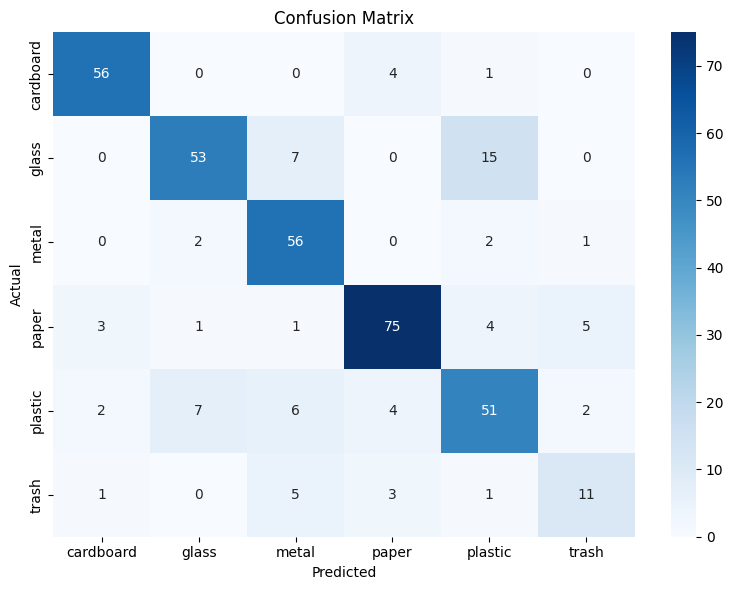

In [39]:
# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

5.파인튜닝
=
- 데이터 수의 제곱근 만큼 손실가중치를 설정했을 때 trash의 정밀도와 재현율이 균형을 이루었지만 유의미한 성능증가 x
- ResNet18의 layer4를 풀어서 손실가중치 유무를 포함한 파인튜닝을 진행하고 성능을 비교

In [43]:
# ===== 1: 파인튜닝 (layer4 + fc, 손실 가중치 없음) =====

# 1. train_transform: 증강 없는 버전 (기준과 동일)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 2. 데이터셋·로더 다시 만들기
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(eval_base, val_idx)
test_dataset  = Subset(eval_base, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# 3. 모델 초기화
num_classes = 6
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# 전체를 먼저 얼림
for param in model.parameters():
    param.requires_grad = False

# fc층 교체
model.fc = nn.Linear(in_features=512, out_features=num_classes)

# layer4만 풀기
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

# 4. 학습되는 층 확인
print("학습되는 층:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print("  ", name)

# 5. 손실 함수(가중치 없음) + 층별 학습률
criterion = nn.CrossEntropyLoss()   # 손실 가중치 없음

optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},  # 기존 층: 작게
    {"params": model.fc.parameters(),     "lr": 0.001},   # 새 층: 크게
])

print("\n준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치 없음")

학습되는 층:
   layer4.0.conv1.weight
   layer4.0.bn1.weight
   layer4.0.bn1.bias
   layer4.0.conv2.weight
   layer4.0.bn2.weight
   layer4.0.bn2.bias
   layer4.0.downsample.0.weight
   layer4.0.downsample.1.weight
   layer4.0.downsample.1.bias
   layer4.1.conv1.weight
   layer4.1.bn1.weight
   layer4.1.bn1.bias
   layer4.1.conv2.weight
   layer4.1.bn2.weight
   layer4.1.bn2.bias
   fc.weight
   fc.bias

준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치 없음


In [44]:
num_epochs = 10

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/10 | 학습 손실: 0.7868 | 검증 손실: 0.4025 | 검증 정확도: 83.91%
에폭 2/10 | 학습 손실: 0.2034 | 검증 손실: 0.3449 | 검증 정확도: 86.54%
에폭 3/10 | 학습 손실: 0.0709 | 검증 손실: 0.3056 | 검증 정확도: 87.86%
에폭 4/10 | 학습 손실: 0.0270 | 검증 손실: 0.3232 | 검증 정확도: 88.13%
에폭 5/10 | 학습 손실: 0.0200 | 검증 손실: 0.3186 | 검증 정확도: 88.39%
에폭 6/10 | 학습 손실: 0.0169 | 검증 손실: 0.3082 | 검증 정확도: 89.97%
에폭 7/10 | 학습 손실: 0.0102 | 검증 손실: 0.3137 | 검증 정확도: 89.71%
에폭 8/10 | 학습 손실: 0.0126 | 검증 손실: 0.3146 | 검증 정확도: 89.71%
에폭 9/10 | 학습 손실: 0.0099 | 검증 손실: 0.3509 | 검증 정확도: 88.65%
에폭 10/10 | 학습 손실: 0.0062 | 검증 손실: 0.3431 | 검증 정확도: 89.18%


              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        61
       glass       0.89      0.87      0.88        75
       metal       0.80      0.87      0.83        61
       paper       0.94      0.94      0.94        89
     plastic       0.84      0.88      0.86        72
       trash       0.83      0.71      0.77        21

    accuracy                           0.89       379
   macro avg       0.89      0.87      0.88       379
weighted avg       0.89      0.89      0.89       379



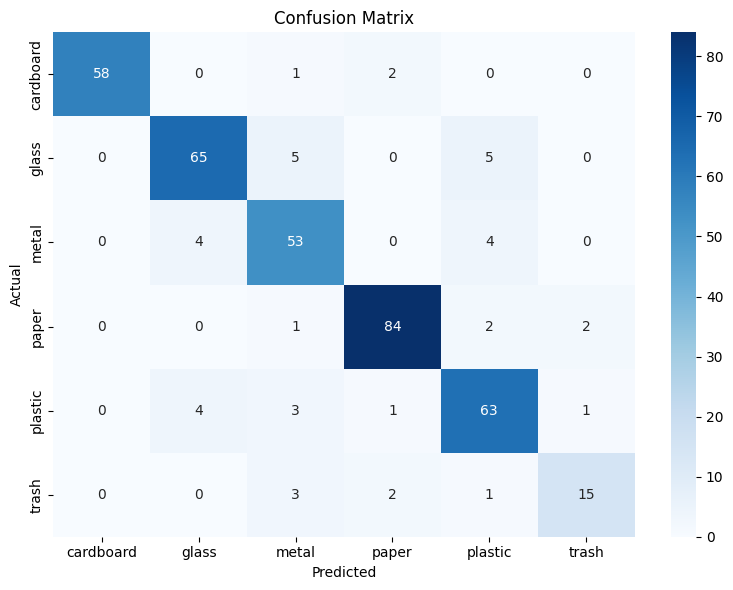

In [45]:
# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

In [53]:
# ===== 2: 파인튜닝(layer4+fc) + 손실 가중치(데이터수의 제곱근) =====

# 1. train_transform: 증강 없는 버전 (동일)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 2. 데이터셋·로더 다시 만들기 (동일)
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(eval_base, val_idx)
test_dataset  = Subset(eval_base, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# 3. 손실 가중치 계산 (제곱근 완화) ← 방향 1에 없던 부분
train_labels = [train_base.targets[i] for i in train_idx]
counts = Counter(train_labels)

num_classes = 6
class_counts = torch.tensor(
    [counts[c] for c in range(num_classes)], dtype=torch.float
)
raw_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = torch.sqrt(raw_weights)          # 제곱근으로 강도 완화
class_weights = class_weights.to(device)

print("완화 후 가중치:", [round(w, 3) for w in class_weights.tolist()])

# 4. 모델 초기화 (방향 1과 동일: layer4 풀기)
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(in_features=512, out_features=num_classes)
for param in model.layer4.parameters():
    param.requires_grad = True
model = model.to(device)

# 5. 손실 함수(가중치 적용) + 층별 학습률 ← criterion만 바뀜
criterion = nn.CrossEntropyLoss(weight=class_weights)   # 여기가 방향 1과 다른 점
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(),     "lr": 0.001},
])

print("준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치(제곱근 완화)")

완화 후 가중치: [1.022, 0.918, 1.013, 0.842, 0.935, 1.752]
준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치(제곱근 완화)


In [54]:
num_epochs = 10

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/10 | 학습 손실: 0.7734 | 검증 손실: 0.4346 | 검증 정확도: 83.91%
에폭 2/10 | 학습 손실: 0.1778 | 검증 손실: 0.3657 | 검증 정확도: 87.07%
에폭 3/10 | 학습 손실: 0.0699 | 검증 손실: 0.3537 | 검증 정확도: 88.92%
에폭 4/10 | 학습 손실: 0.0346 | 검증 손실: 0.3994 | 검증 정확도: 88.65%
에폭 5/10 | 학습 손실: 0.0191 | 검증 손실: 0.3733 | 검증 정확도: 88.92%
에폭 6/10 | 학습 손실: 0.0133 | 검증 손실: 0.3317 | 검증 정확도: 90.24%
에폭 7/10 | 학습 손실: 0.0091 | 검증 손실: 0.3380 | 검증 정확도: 88.92%
에폭 8/10 | 학습 손실: 0.0058 | 검증 손실: 0.3501 | 검증 정확도: 90.50%
에폭 9/10 | 학습 손실: 0.0112 | 검증 손실: 0.3572 | 검증 정확도: 89.97%
에폭 10/10 | 학습 손실: 0.0190 | 검증 손실: 0.3924 | 검증 정확도: 88.65%


In [50]:
# ===== 2-에폭5: 파인튜닝(layer4+fc) + 손실 가중치(데이터수의 제곱근) =====

# 1. train_transform: 증강 없는 버전 (동일)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# 2. 데이터셋·로더 다시 만들기 (동일)
train_base = datasets.ImageFolder(data_dir, transform=train_transform)

train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(eval_base, val_idx)
test_dataset  = Subset(eval_base, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# 3. 손실 가중치 계산 (제곱근 완화) ← 방향 1에 없던 부분
train_labels = [train_base.targets[i] for i in train_idx]
counts = Counter(train_labels)

num_classes = 6
class_counts = torch.tensor(
    [counts[c] for c in range(num_classes)], dtype=torch.float
)
raw_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = torch.sqrt(raw_weights)          # 제곱근으로 강도 완화
class_weights = class_weights.to(device)

print("완화 후 가중치:", [round(w, 3) for w in class_weights.tolist()])

# 4. 모델 초기화 (방향 1과 동일: layer4 풀기)
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(in_features=512, out_features=num_classes)
for param in model.layer4.parameters():
    param.requires_grad = True
model = model.to(device)

# 5. 손실 함수(가중치 적용) + 층별 학습률 ← criterion만 바뀜
criterion = nn.CrossEntropyLoss(weight=class_weights)   # 여기가 방향 1과 다른 점
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(),     "lr": 0.001},
])

print("준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치(제곱근 완화)")

완화 후 가중치: [1.022, 0.918, 1.013, 0.842, 0.935, 1.752]
준비 완료 - 파인튜닝(layer4+fc) + 손실 가중치(제곱근 완화)


In [51]:
num_epochs = 5  # 10번 진행 결과 6바퀴에서 과적합 시작

for epoch in range(num_epochs):
    # ===== 학습 =====
    model.train()                          # 학습 모드
    train_loss = 0.0                       # 학습 손실 누적용

    for images, labels in train_loader:
        images = images.to(device)         # 이미지를 GPU로 이동
        labels = labels.to(device)         # 정답을 GPU로 이동

        optimizer.zero_grad()              # 이전 배치 기울기 초기화
        outputs = model(images)            # 예측 (순전파)
        loss = criterion(outputs, labels)  # 손실 계산
        loss.backward()                    # 수정 방향 계산 (역전파)
        optimizer.step()                   # 가중치 수정

        train_loss += loss.item()          # 배치 손실 누적

    avg_train_loss = train_loss / len(train_loader)   # 학습 평균 손실

    # ===== 검증  =====
    model.eval()                           # 평가 모드
    val_loss = 0.0                         # 검증 손실 누적용
    correct = 0                            # 맞힌 개수
    total = 0                              # 전체 개수

    with torch.no_grad():                  # 기울기 계산 끄기
        for images, labels in val_loader:
            images = images.to(device)     # 이미지를 GPU로 이동
            labels = labels.to(device)     # 정답을 GPU로 이동

            outputs = model(images)        # 예측
            loss = criterion(outputs, labels)  # 손실 계산
            val_loss += loss.item()        # 배치 손실 누적

            _, predicted = torch.max(outputs, 1)   # 가장 높은 점수의 종류 = 예측
            total += labels.size(0)                # 이번 배치 개수 누적
            correct += (predicted == labels).sum().item()  # 맞힌 개수 누적

    avg_val_loss = val_loss / len(val_loader)   # 검증 평균 손실
    val_acc = 100 * correct / total             # 검증 정확도(%)

    # ===== 결과 출력 =====
    print(f"에폭 {epoch+1}/{num_epochs} | "
          f"학습 손실: {avg_train_loss:.4f} | "
          f"검증 손실: {avg_val_loss:.4f} | "
          f"검증 정확도: {val_acc:.2f}%")

에폭 1/5 | 학습 손실: 0.8175 | 검증 손실: 0.4693 | 검증 정확도: 81.53%
에폭 2/5 | 학습 손실: 0.1905 | 검증 손실: 0.3326 | 검증 정확도: 86.81%
에폭 3/5 | 학습 손실: 0.0674 | 검증 손실: 0.3110 | 검증 정확도: 88.39%
에폭 4/5 | 학습 손실: 0.0396 | 검증 손실: 0.3199 | 검증 정확도: 89.18%
에폭 5/5 | 학습 손실: 0.0264 | 검증 손실: 0.3339 | 검증 정확도: 90.50%


              precision    recall  f1-score   support

   cardboard       0.98      0.95      0.97        61
       glass       0.90      0.84      0.87        75
       metal       0.83      0.93      0.88        61
       paper       0.93      0.97      0.95        89
     plastic       0.88      0.89      0.88        72
       trash       0.94      0.71      0.81        21

    accuracy                           0.91       379
   macro avg       0.91      0.88      0.89       379
weighted avg       0.91      0.91      0.90       379



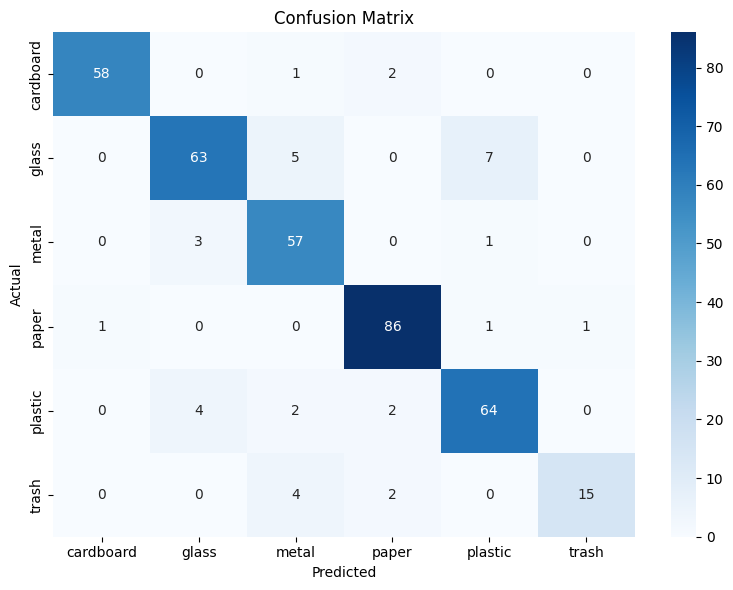

In [52]:
# 클래스 이름 (ImageFolder가 정한 순서 = 알파벳순 0~5번)
class_names = train_base.classes

model.eval()                          # 평가 모드
all_preds = []                        # 모델 예측 모으기
all_labels = []                       # 실제 정답 모으기

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)   # 예측 종류

        all_preds.extend(predicted.cpu().numpy())   # GPU→CPU→넘파이로 모음
        all_labels.extend(labels.cpu().numpy())

# 1. 클래스별 정확도 + 요약 표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. 혼동 행렬 계산 (행=실제, 열=예측)
cm = confusion_matrix(all_labels, all_preds)

# 3. 혼동 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))            # 그림 크기 (가로 8, 세로 6 인치)
sns.heatmap(
    cm,                               # 그릴 데이터 = 혼동 행렬
    annot=True,                       # 각 칸에 숫자 표시
    fmt="d",                          # 숫자를 정수 형식으로 (소수점 없이)
    cmap="Blues",                     # 색 계열 = 파랑 (값 클수록 진함)
    xticklabels=class_names,          # 가로축 눈금 = 클래스 이름 (예측)
    yticklabels=class_names,          # 세로축 눈금 = 클래스 이름 (실제)
)
plt.xlabel("Predicted")               # 가로축 이름 (예측)
plt.ylabel("Actual")                  # 세로축 이름 (실제)
plt.title("Confusion Matrix")         # 그림 제목
plt.tight_layout()                    # 라벨 잘림 방지로 여백 정리
plt.show()                            # 그림 화면에 출력

              precision    recall  f1-score   support

   cardboard       0.92      0.92      0.92        60
       glass       0.92      0.79      0.85        76
       metal       0.80      0.92      0.86        62
       paper       0.90      0.91      0.91        89
     plastic       0.86      0.90      0.88        73
       trash       0.94      0.80      0.86        20

    accuracy                           0.88       380
   macro avg       0.89      0.87      0.88       380
weighted avg       0.89      0.88      0.88       380



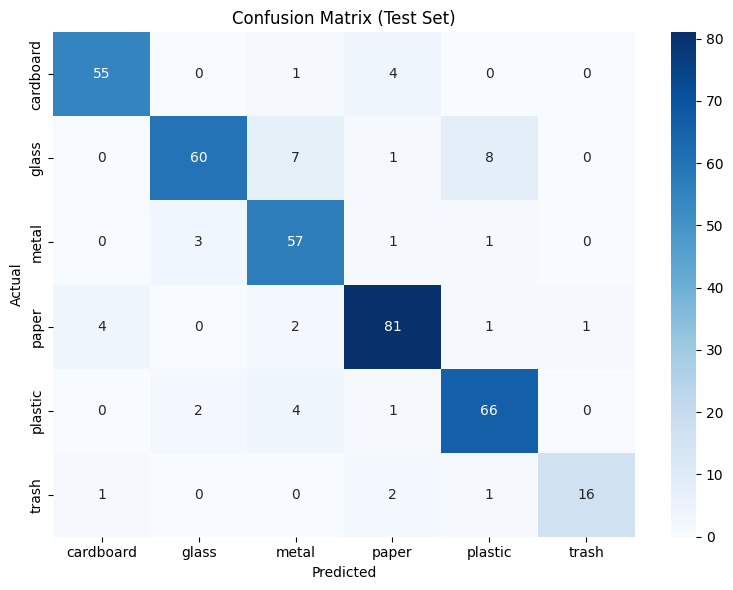

In [55]:
# ===== 모델 선택 후 최종 성능 측정: 테스트셋 =====

model.eval()                          # 평가 모드
all_preds = []
all_labels = []

with torch.no_grad():                 # 기울기 계산 끄기
    for images, labels in test_loader:    # val_loader가 아니라 test_loader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 클래스별 성적표
print(classification_report(all_labels, all_preds, target_names=class_names))

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")   # 제목에 Test 명시
plt.tight_layout()
plt.show()

In [56]:
# ===== 모델 저장 (.pth) =====

# 드라이브의 프로젝트 폴더에 저장 (런타임이 꺼져도 유지됨)
save_path = "/content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/garbage_resnet18_final.pth"

# 모델의 가중치(state_dict)만 저장 - 구조는 코드로 재현 가능하므로 가중치만 저장하는 게 표준
torch.save(model.state_dict(), save_path)

print("저장 완료:", save_path)

저장 완료: /content/drive/MyDrive/MAIN/PROJECT/AI-Project/2026.08.Garbage-classification-model/garbage_resnet18_final.pth


# 실험 종합 기록 및 최종 결론 (2026.08.15)

## 개요
- 과제: TrashNet 기반 쓰레기 이미지 6종 분류 (cardboard, glass, metal, paper, plastic, trash)
- 기반: ImageNet 사전학습 ResNet18 전이학습
- 데이터: 총 2,527장, train/val/test = 70/15/15 층화 분할 (1,768 / 379 / 380)
- 클래스 불균형: paper 594장 ~ trash 137장
- 실험 1~6의 성적은 검증셋 기준. 테스트셋은 모든 튜닝이 끝난 후 최종 측정에 1회만 사용
- 공통 조건: 입력 224×224, ImageNet 정규화, batch 32, Adam(lr=0.001)

---

## 실험 1. 기준점 - 전이학습, fc만 학습
조건: conv1~layer4 전체 freeze, fc(512→6)만 학습. 증강 없음, 손실 가중치 없음. 10에폭.

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 1.00 | 0.85 | 0.92 |
| glass | 0.76 | 0.76 | 0.76 |
| metal | 0.70 | 0.82 | 0.76 |
| paper | 0.82 | 0.94 | 0.88 |
| plastic | 0.72 | 0.67 | 0.69 |
| trash | 0.75 | 0.43 | 0.55 |

accuracy 0.79 | macro f1 0.76

-> trash recall = 0.43으로 소수 클래스(학습셋 96장)가 다수 클래스에 밀려 소극적으로 예측됨.

---

## 실험 2. 데이터 증강
조건: RandomHorizontalFlip(0.5) + RandomRotation(15) + ColorJitter(밝기·대비 0.2). 학습셋에만 적용. 10에폭.

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 0.98 | 0.74 | 0.84 |
| glass | 0.81 | 0.59 | 0.68 |
| metal | 0.57 | 0.92 | 0.70 |
| paper | 0.84 | 0.78 | 0.81 |
| plastic | 0.65 | 0.75 | 0.70 |
| trash | 0.67 | 0.48 | 0.56 |

accuracy 0.73 | macro f1 0.71

-> trash class 성능 개선 미미(recall 0.43→0.48), 전체 하락(0.79→0.73). 데이터증강의 문제점이라기 보다는 원본데이터의 개수문제로 해석됨.

---

## 실험 3. 손실 가중치
조건: CrossEntropyLoss(weight = 전체장수/(6×클래스장수)). trash 가중치 약 3.1. 10에폭.

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 0.95 | 0.87 | 0.91 |
| glass | 0.79 | 0.71 | 0.75 |
| metal | 0.71 | 0.74 | 0.73 |
| paper | 0.89 | 0.82 | 0.85 |
| plastic | 0.67 | 0.75 | 0.71 |
| trash | 0.47 | 0.67 | 0.55 |

accuracy 0.77 | macro f1 0.75

-> trash recall 0.43→0.67 상승, precision 0.75→0.47 하락. trash class의 가중치가 지나치게 높아 다른 class도 trash로 찍는 현상. recall 상승 / precision 하락의 원인으로 볼 수 있음. trash f1은 0.55로 불변.

---

## 실험 4. 손실 가중치 완화 - 제곱근
조건: 실험 3의 가중치에 제곱근 적용. trash 가중치 약 1.75로 완화. 10에폭

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 0.90 | 0.92 | 0.91 |
| glass | 0.84 | 0.71 | 0.77 |
| metal | 0.75 | 0.92 | 0.82 |
| paper | 0.87 | 0.84 | 0.86 |
| plastic | 0.69 | 0.71 | 0.70 |
| trash | 0.58 | 0.52 | 0.55 |

accuracy 0.80 | macro f1 0.77

해석: 가중치 강도에 비례해 trash가 원본(0.47/0.67)과 기준점(0.75/0.43) 사이 중간 지점(0.58/0.52)으로 이동. f1은 여전히 0.55. fc만 학습하는 구조에서는 가중치 조절이 recall·precision의 배분만 바꿀 뿐 종합 성능(f1)을 올리지 못함을 확인.

## 실험 5. 파인튜닝 — layer4+fc 해제, 가중치 없음 (10에폭)
조건: layer4 freeze 해제. 층별 학습률 layer4=0.0001, fc=0.001. 손실 가중치 없음.

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 1.00 | 0.95 | 0.97 |
| glass | 0.89 | 0.87 | 0.88 |
| metal | 0.80 | 0.87 | 0.83 |
| paper | 0.94 | 0.94 | 0.94 |
| plastic | 0.84 | 0.88 | 0.86 |
| trash | 0.83 | 0.71 | 0.77 |

accuracy 0.89 | macro f1 0.88

-> 전 성능지표 상승(accuracy 0.80→0.89, macro f1 0.77→0.88). trash는 가중치 없이 precision(0.75→0.83)과 recall(0.43→0.71)이 동시 상승. trash class의 낮은 성능의 근본 원인이 데이터 부족만이 아니라 특징 구별 능력 부족이었음이 확인됨.

학습 손실이 4에폭 만에 0.02대로 급락, 검증 손실은 3에폭(0.3056) 최저 후 반등 — 표현력 증가로 과적합이 빠르게 시작됨.

---

## 실험 6. 파인튜닝 + 제곱근 가중치
조건: 실험 5 + 제곱근 완화 손실 가중치.5에폭.

6-1. 에폭 10 실행 — 과적합 시작점 확인용
검증 손실이 6에폭(0.3317) 최저 후 반등(10에폭 0.3924). 이를 근거로 에폭을 5로 재설정(수동 조기 종료).

6-2. 에폭 5 재실행 — 최종 모델

| 클래스 | precision | recall | f1 |
|---|---|---|---|
| cardboard | 0.98 | 0.95 | 0.97 |
| glass | 0.90 | 0.84 | 0.87 |
| metal | 0.83 | 0.93 | 0.88 |
| paper | 0.93 | 0.97 | 0.95 |
| plastic | 0.88 | 0.89 | 0.88 |
| trash | 0.94 | 0.71 | 0.81 |

accuracy 0.91 | macro f1 0.89 (검증셋 기준)

---

## 최종 성능 측정 - 테스트셋
테스트셋(380장)으로 1회 측정.

| 클래스 | precision | recall | f1 | support |
|---|---|---|---|---|
| cardboard | 0.92 | 0.92 | 0.92 | 60 |
| glass | 0.92 | 0.79 | 0.85 | 76 |
| metal | 0.80 | 0.92 | 0.86 | 62 |
| paper | 0.90 | 0.91 | 0.91 | 89 |
| plastic | 0.86 | 0.90 | 0.88 | 73 |
| trash | 0.94 | 0.80 | 0.86 | 20 |

accuracy 0.88 | macro f1 0.88

검증 vs 테스트 비교(최종 모델):
- accuracy 0.91 → 0.88, macro f1 0.89 → 0.88
- trash: f1 0.81 → 0.86 (recall 0.71→0.80, precision 0.94 유지)

->
- 테스트 정확도가 검증보다 소폭 낮음(-0.03). 에폭·가중치·freeze 범위를 전부 검증셋을 보고 결정했으므로 검증 성적에 비해 테스트 성적이 낮음. 그러나, 그 격차가 작아 튜닝이 검증셋에 과도하게 맞춰지진 않았다고 해석할 수 있음.
- glass가 최약 클래스(recall 0.79): glass→metal 7장, glass→plastic 8장. 재질 유사성에 의한 혼동은 검증·테스트 모두에서 일관되게 나타나는 이 데이터의 구조적 한계로 해석할 수 있음

---

## 종합 비교

| # | 실험 | 셋 | 에폭 | acc | macro f1 | trash P | trash R | trash f1 |
|---|---|---|---|---|---|---|---|---|
| 1 | 기준점 (fc만) | val | 10 | 0.79 | 0.76 | 0.75 | 0.43 | 0.55 |
| 2 | 증강 | val | 15 | 0.73 | 0.71 | 0.67 | 0.48 | 0.56 |
| 3 | 가중치 원본 | val | 10 | 0.77 | 0.75 | 0.47 | 0.67 | 0.55 |
| 4 | 가중치 완화 | val | 10 | 0.80 | 0.77 | 0.58 | 0.52 | 0.55 |
| 5 | 파인튜닝 | val | 10 | 0.89 | 0.88 | 0.83 | 0.71 | 0.77 |
| 6 | 파인튜닝+완화 | val | 5 | 0.91 | 0.89 | 0.94 | 0.71 | 0.81 |
| 최종 | 6번 모델 테스트 측정 | test | - | 0.88 | 0.88 | 0.94 | 0.80 | 0.86 |

---

## 분석

- 1기(실험 1 ~ 4) - 학습 규칙 조정: fc만 학습한 시기. trash f1이 0.55~0.56에 고정된 채 precision과 recall의 배분만 이동(0.75/0.43 → 0.47/0.67 → 0.58/0.52). 모델의 구별 능력 총량이 고정된 상태에서, 증강과 가중치는 그 능력을 어디에 쓸지만 바꿨음.

- 2기(실험 5 ~ 6) - 표현력 확장: layer4를 풀어 특징 추출 자체를 데이터에 맞게 조정. 능력 총량이 늘어나 trash의 precision·recall이 맞바꿈 없이 동시 상승, 전 클래스 개선. 대신 과적합이 3~6에폭에서 시작되어 에폭 축소(조기 종료)로 대응.

- 검증 및 테스트: 최종 일반화 성능은 accuracy 0.88. 검증 대비 -0.03의 격차는 검증셋 기반 튜닝의 낙관 보정으로 해석되며, 격차가 작아 모델 선택 과정은 건전했다고 판단.

한계:
- 실험 5(10에폭)와 6(5에폭)은 가중치 유무와 에폭 수, 두 변수가 동시에 달라 최종 개선분의 원인(가중치 vs 조기 종료)이 분리되지 않음.
- trash 표본이 20~21장으로 적어 trash 지표는 ±0.05 이상의 변동 폭을 가짐.
- glass↔metal↔plastic 상호 혼동은 재질 유사성에서 오는 구조적 한계.

---

## 최종 결론
- 채택 모델: ResNet18 파인튜닝(layer4+fc, 층별 학습률 0.0001/0.001) + 제곱근 완화 손실 가중치, 5에폭
- 최종 성능(테스트셋): accuracy 0.88, macro f1 0.88, trash f1 0.86
-  개선 방향: trash 원본 데이터 확충(증강이 아닌 수집), glass 계열 혼동 완화를 위한 추가 파인튜닝(layer3 해제 실험), 조기 종료 자동화(early stopping 구현)